# Amplitude comparison: local mseed vs SUD vs FDSN

Investigates a suspected amplitude discrepancy between the Seismosphere visualisation and ObsPy for VW.BEST.

Three pipelines, all reduced to ground velocity (m/s):

1. **Local mseed + local FDSN StationXML** (`BEST.xml`).
2. **Local SUD + sudspy-derived ObsPy inventory** (`sudspy.read_suds_inv`).
3. **FDSN waveform + FDSN inventory** from `https://subsurface.science.unimelb.edu.au`.

For each path we report min, max, peak-to-peak counts (pre-correction) and m/s (post `remove_response`).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

import obspy
from obspy import read, read_inventory, UTCDateTime
from obspy.clients.fdsn import Client

import sudspy

print('obspy', obspy.__version__)
print('sudspy from', sudspy.__file__)

obspy 1.4.2
sudspy from /Users/DSAND/projects/SubSurfObs/sudspy/sudspy/__init__.py


In [2]:
# Paths
TEST_DIR = Path('test_amplitude_src')
MSEED_DIR = TEST_DIR / '2026-05-09 0800_BEST.ms'
MSEED_FILE = MSEED_DIR / 'mszip.16222778378020441172.ms'
LOCAL_XML = MSEED_DIR / 'BEST.xml'                       # local stationxml that ships with the mseed bundle
SUD_FILE = TEST_DIR / '20260509_0812.all.seismosphere.v.sud'

# Fallback to the network-level XML if the per-station one is unavailable
REPO_VW_XML = Path('..') / 'fdsnxml' / 'vw.xml'

FDSN_BASE = 'https://subsurface.science.unimelb.edu.au'

for p in [MSEED_FILE, LOCAL_XML, SUD_FILE, REPO_VW_XML]:
    print(f'{"OK" if p.exists() else "MISSING":<7} {p}')

OK      test_amplitude_src/2026-05-09 0800_BEST.ms/mszip.16222778378020441172.ms
OK      test_amplitude_src/2026-05-09 0800_BEST.ms/BEST.xml
OK      test_amplitude_src/20260509_0812.all.seismosphere.v.sud
OK      ../fdsnxml/vw.xml


## 1. Read the two local waveform files and isolate the Z channel

In [3]:
# --- mseed ---
st_ms = read(str(MSEED_FILE))
print('mseed file traces:')
print(st_ms.__str__(extended=True))

mseed file traces:
3 Trace(s) in Stream:
VW.BEST.00.CHE | 2026-05-09T08:11:04.576000Z - 2026-05-09T08:15:03.232000Z | 250.0 Hz, 59665 samples
VW.BEST.00.CHN | 2026-05-09T08:11:05.700000Z - 2026-05-09T08:15:02.900000Z | 250.0 Hz, 59301 samples
VW.BEST.00.CHZ | 2026-05-09T08:11:04.552000Z - 2026-05-09T08:15:02.572000Z | 250.0 Hz, 59506 samples


In [4]:
# --- SUD ---
st_sud = sudspy.read_suds_stream(str(SUD_FILE), default_location='00')
print('SUD file traces:')
print(st_sud.__str__(extended=True))

SUD file traces:
1 Trace(s) in Stream:
VW.BEST.00.CHZ | 2026-05-09T08:12:00.000000Z - 2026-05-09T08:14:59.996000Z | 250.0 Hz, 45000 samples


In [5]:
def pick_z(stream):
    """Return the first vertical-component trace, regardless of band code."""
    z = stream.select(component='Z')
    if len(z) == 0:
        # Sometimes SUDS uses 'V' for vertical
        z = stream.select(component='V')
    if len(z) == 0:
        raise RuntimeError(f'No Z/V channel in stream:\n{stream}')
    return z.merge(method=1, fill_value=0)[0]

tr_ms = pick_z(st_ms)
tr_sud = pick_z(st_sud)

print('mseed Z :', tr_ms.id, tr_ms.stats.starttime, '->', tr_ms.stats.endtime, '|', tr_ms.stats.sampling_rate, 'Hz', '|', tr_ms.stats.npts, 'pts')
print('SUD   Z :', tr_sud.id, tr_sud.stats.starttime, '->', tr_sud.stats.endtime, '|', tr_sud.stats.sampling_rate, 'Hz', '|', tr_sud.stats.npts, 'pts')

mseed Z : VW.BEST.00.CHZ 2026-05-09T08:11:04.552000Z -> 2026-05-09T08:15:02.572000Z | 250.0 Hz | 59506 pts
SUD   Z : VW.BEST.00.CHZ 2026-05-09T08:12:00.000000Z -> 2026-05-09T08:14:59.996000Z | 250.0 Hz | 45000 pts


In [6]:
def amp_stats(trace, label):
    d = np.asarray(trace.data)
    return {
        'label': label,
        'id': trace.id,
        'starttime': str(trace.stats.starttime),
        'endtime': str(trace.stats.endtime),
        'npts': int(trace.stats.npts),
        'min': float(d.min()),
        'max': float(d.max()),
        'peak_abs': float(np.abs(d).max()),
        'peak_to_peak': float(d.max() - d.min()),
    }

raw_rows = [
    amp_stats(tr_ms, 'mseed counts'),
    amp_stats(tr_sud, 'SUD counts'),
]
pd.DataFrame(raw_rows)

,label,id,starttime,endtime,npts,min,max,peak_abs,peak_to_peak
0,mseed counts,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-519178.0,354249.0,519178.0,873427.0
1,SUD counts,VW.BEST.00.CHZ,2026-05-09T08:12:00.000000Z,2026-05-09T08:14:59.996000Z,45000,-519178.0,354249.0,519178.0,873427.0


## 2. Build the three inventories

- **inv_local** — from the local `BEST.xml` (falls back to the repo-level `vw.xml` if needed).
- **inv_sud** — from the SUD file via `sudspy.read_suds_inv`.
- **inv_fdsn** — fetched from the UoM FDSN service.

In [7]:
if LOCAL_XML.exists():
    inv_local = read_inventory(str(LOCAL_XML))
    print(f'Loaded local stationxml from {LOCAL_XML}')
else:
    inv_local = read_inventory(str(REPO_VW_XML))
    print(f'Fell back to network stationxml {REPO_VW_XML}')
print(inv_local)

Loaded local stationxml from test_amplitude_src/2026-05-09 0800_BEST.ms/BEST.xml
Inventory created at 2025-07-23T07:19:43.000000Z
	Created by: eqLogger 15
		    
	Sending institution: eqlogger (eqlogger)
	Contains:
		Networks (1):
			VW
		Stations (1):
			VW.BEST ()
		Channels (3):
			VW.BEST.00.CHZ, VW.BEST.00.CHN, VW.BEST.00.CHE


In [8]:
inv_sud = sudspy.read_suds_inv(str(SUD_FILE), default_location='00')
print(inv_sud)

Inventory created at 2026-05-18T04:27:58.852280Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: SUDS
	Contains:
		Networks (1):
			VW
		Stations (1):
			VW.BEST (BEST)
		Channels (1):
			VW.BEST.00.CHZ


In [9]:
client = Client(FDSN_BASE)

# Use the mseed window for the inventory query; the FDSN xml will of course cover both files.
net = tr_ms.stats.network
sta = tr_ms.stats.station
cha_z = tr_ms.stats.channel
loc = tr_ms.stats.location or '*'

inv_fdsn = client.get_stations(
    network=net,
    station=sta,
    location=loc,
    channel=cha_z,
    starttime=tr_ms.stats.starttime - 60,
    endtime=tr_ms.stats.endtime + 60,
    level='response',
)
print(inv_fdsn)

Inventory created at 2026-05-18T04:27:59.000965Z
	Sending institution: SeisComP (UOM)
	Contains:
		Networks (1):
			VW
		Stations (1):
			VW.BEST (VW-BEST)
		Channels (1):
			VW.BEST.00.CHZ


In [10]:
def channel_sensitivity(inv, net, sta, cha):
    """Return overall instrument sensitivity (counts / (m/s)) for the first matching channel."""
    for n in inv:
        if n.code != net:
            continue
        for s in n.stations:
            if s.code != sta:
                continue
            for c in s.channels:
                if c.code == cha and c.response is not None and c.response.instrument_sensitivity:
                    return c.response.instrument_sensitivity.value
    return None

for tag, inv in [('local', inv_local), ('sudspy', inv_sud), ('fdsn', inv_fdsn)]:
    # try the mseed channel id first, then the SUD-derived one
    cha_tries = [tr_ms.stats.channel, tr_sud.stats.channel]
    sens = None
    used = None
    for ch in cha_tries:
        sens = channel_sensitivity(inv, tr_ms.stats.network, tr_ms.stats.station, ch)
        if sens is not None:
            used = ch
            break
    print(f'{tag:<7} sensitivity for {tr_ms.stats.network}.{tr_ms.stats.station}.{used} = {sens}')

local   sensitivity for VW.BEST.CHZ = 972910720.0
sudspy  sensitivity for VW.BEST.CHZ = 972910756.1323961
fdsn    sensitivity for VW.BEST.CHZ = 976293600.0


## 3. Instrument correction for each (waveform, inventory) pair

We correct the **mseed Z trace** with all three inventories, the **SUD Z trace** with the matching inventory, and the **FDSN-pulled Z trace** with the FDSN inventory.

All corrections use `output='VEL'` (m/s) with the same prefilter and water level so that the only deliberate difference is the inventory.

In [11]:
PRE_FILT = (0.05, 0.1, 80.0, 100.0)   # adjust to your standard if different
WATER_LEVEL = 60
OUTPUT = 'VEL'

def corrected_copy(trace, inv, label):
    tr = trace.copy()
    tr.remove_response(
        inventory=inv,
        output=OUTPUT,
        water_level=WATER_LEVEL,
        pre_filt=PRE_FILT,
        zero_mean=True,
        taper=True,
    )
    return tr, amp_stats(tr, label)

In [12]:
# Pull FDSN waveform covering both file windows
t0 = min(tr_ms.stats.starttime, tr_sud.stats.starttime)
t1 = max(tr_ms.stats.endtime,   tr_sud.stats.endtime)

st_fdsn = client.get_waveforms(
    network=tr_ms.stats.network,
    station=tr_ms.stats.station,
    location=tr_ms.stats.location or '*',
    channel=tr_ms.stats.channel,
    starttime=t0,
    endtime=t1,
)
print(st_fdsn.__str__(extended=True))
tr_fdsn = pick_z(st_fdsn)
print('FDSN Z  :', tr_fdsn.id, tr_fdsn.stats.starttime, '->', tr_fdsn.stats.endtime, '|', tr_fdsn.stats.sampling_rate, 'Hz', '|', tr_fdsn.stats.npts, 'pts')

1 Trace(s) in Stream:
VW.BEST.00.CHZ | 2026-05-09T08:11:04.552000Z - 2026-05-09T08:15:02.572000Z | 250.0 Hz, 59506 samples
FDSN Z  : VW.BEST.00.CHZ 2026-05-09T08:11:04.552000Z -> 2026-05-09T08:15:02.572000Z | 250.0 Hz | 59506 pts


In [13]:
rows = []

# Raw counts
rows.append({'pipeline': 'mseed (counts)',     'inventory': '-',      **amp_stats(tr_ms,   'mseed counts')})
rows.append({'pipeline': 'SUD (counts)',       'inventory': '-',      **amp_stats(tr_sud,  'SUD counts')})
rows.append({'pipeline': 'FDSN (counts)',      'inventory': '-',      **amp_stats(tr_fdsn, 'FDSN counts')})

# mseed corrected with each inventory
for tag, inv in [('local-xml', inv_local), ('sudspy-inv', inv_sud), ('fdsn-inv', inv_fdsn)]:
    try:
        _tr, stats = corrected_copy(tr_ms, inv, f'mseed/{tag}')
        rows.append({'pipeline': 'mseed -> VEL', 'inventory': tag, **stats})
    except Exception as exc:
        rows.append({'pipeline': 'mseed -> VEL', 'inventory': tag, 'label': f'mseed/{tag}', 'id': tr_ms.id, 'error': str(exc)})

# SUD corrected with each inventory
for tag, inv in [('local-xml', inv_local), ('sudspy-inv', inv_sud), ('fdsn-inv', inv_fdsn)]:
    try:
        _tr, stats = corrected_copy(tr_sud, inv, f'SUD/{tag}')
        rows.append({'pipeline': 'SUD -> VEL',   'inventory': tag, **stats})
    except Exception as exc:
        rows.append({'pipeline': 'SUD -> VEL',   'inventory': tag, 'label': f'SUD/{tag}', 'id': tr_sud.id, 'error': str(exc)})

# FDSN waveform corrected with the FDSN inventory (the canonical pipeline)
try:
    _tr, stats = corrected_copy(tr_fdsn, inv_fdsn, 'FDSN/fdsn-inv')
    rows.append({'pipeline': 'FDSN -> VEL', 'inventory': 'fdsn-inv', **stats})
except Exception as exc:
    rows.append({'pipeline': 'FDSN -> VEL', 'inventory': 'fdsn-inv', 'label': 'FDSN/fdsn-inv', 'id': tr_fdsn.id, 'error': str(exc)})

df = pd.DataFrame(rows)
df

,pipeline,inventory,label,id,starttime,endtime,npts,min,max,peak_abs,peak_to_peak
0,mseed (counts),-,mseed counts,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-519178.000000,354249.000000,519178.000000,873427.000000
1,SUD (counts),-,SUD counts,VW.BEST.00.CHZ,2026-05-09T08:12:00.000000Z,2026-05-09T08:14:59.996000Z,45000,-519178.000000,354249.000000,519178.000000,873427.000000
2,FDSN (counts),-,FDSN counts,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-519178.000000,354249.000000,519178.000000,873427.000000
3,mseed -> VEL,local-xml,mseed/local-xml,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-0.000534,0.000364,0.000534,0.000898
4,mseed -> VEL,sudspy-inv,mseed/sudspy-inv,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-0.000534,0.000364,0.000534,0.000898
5,mseed -> VEL,fdsn-inv,mseed/fdsn-inv,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-0.000407,0.000404,0.000407,0.000811
6,SUD -> VEL,local-xml,SUD/local-xml,VW.BEST.00.CHZ,2026-05-09T08:12:00.000000Z,2026-05-09T08:14:59.996000Z,45000,-0.000534,0.000364,0.000534,0.000898
7,SUD -> VEL,sudspy-inv,SUD/sudspy-inv,VW.BEST.00.CHZ,2026-05-09T08:12:00.000000Z,2026-05-09T08:14:59.996000Z,45000,-0.000534,0.000364,0.000534,0.000898
8,SUD -> VEL,fdsn-inv,SUD/fdsn-inv,VW.BEST.00.CHZ,2026-05-09T08:12:00.000000Z,2026-05-09T08:14:59.996000Z,45000,-0.000407,0.000404,0.000407,0.000811
9,FDSN -> VEL,fdsn-inv,FDSN/fdsn-inv,VW.BEST.00.CHZ,2026-05-09T08:11:04.552000Z,2026-05-09T08:15:02.572000Z,59506,-0.000407,0.000404,0.000407,0.000811


## 4. Comparison

Two things to look for:

1. **Raw counts** in mseed vs SUD vs FDSN should match to single-sample precision if all three pipelines really are exposing the same datalogger output.
2. **Corrected m/s** should agree across inventories within numerical tolerance. A ratio between two corrected peaks is the sensitivity ratio between the two inventories — useful when chasing down a website-vs-ObsPy mismatch.

In [14]:
# Ratio matrix of peak-to-peak (m/s) — quickly shows where inventories diverge
vel_df = df[df['pipeline'].str.contains('VEL')].copy()
vel_df['key'] = vel_df['pipeline'] + ' | ' + vel_df['inventory']
pivot = vel_df.set_index('key')['peak_to_peak']
ratio = pd.DataFrame(
    {k: pivot / v for k, v in pivot.items()},
    index=pivot.index,
)
ratio.round(4)

,mseed -> VEL | local-xml,mseed -> VEL | sudspy-inv,mseed -> VEL | fdsn-inv,SUD -> VEL | local-xml,SUD -> VEL | sudspy-inv,SUD -> VEL | fdsn-inv,FDSN -> VEL | fdsn-inv
key,,,,,,,
mseed -> VEL | local-xml,1.0000,1.0000,1.1073,1.0000,1.0000,1.1073,1.1073
mseed -> VEL | sudspy-inv,1.0000,1.0000,1.1073,1.0000,1.0000,1.1073,1.1073
mseed -> VEL | fdsn-inv,0.9031,0.9031,1.0000,0.9031,0.9031,1.0000,1.0000
SUD -> VEL | local-xml,1.0000,1.0000,1.1073,1.0000,1.0000,1.1073,1.1073
SUD -> VEL | sudspy-inv,1.0000,1.0000,1.1073,1.0000,1.0000,1.1073,1.1073
SUD -> VEL | fdsn-inv,0.9031,0.9031,1.0000,0.9031,0.9031,1.0000,1.0000
FDSN -> VEL | fdsn-inv,0.9031,0.9031,1.0000,0.9031,0.9031,1.0000,1.0000


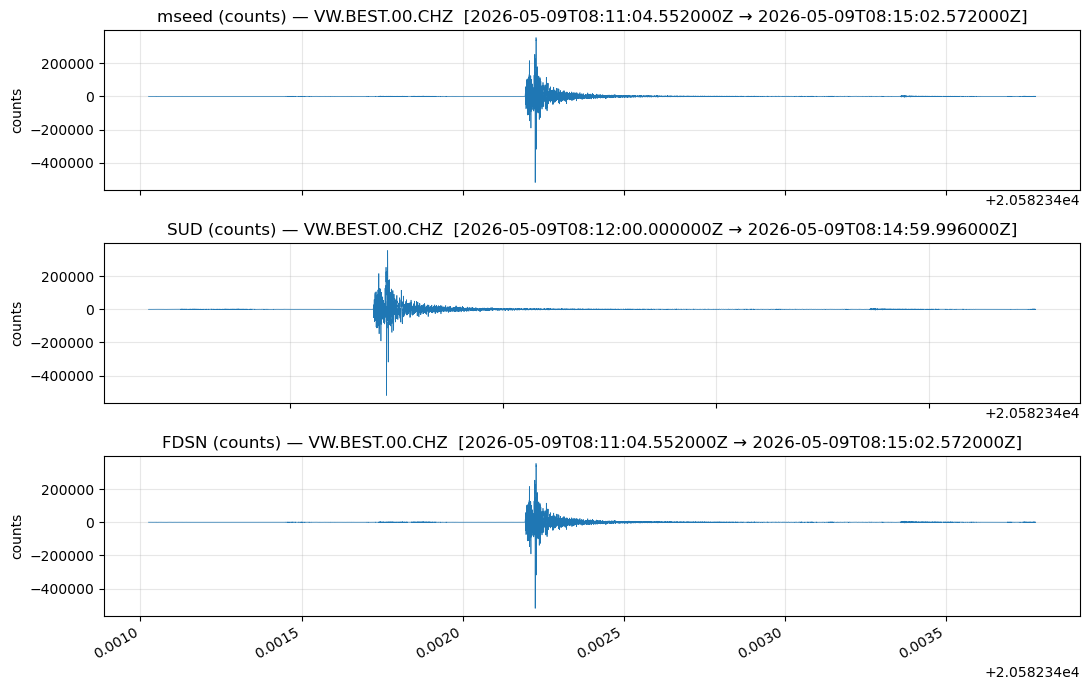

In [15]:
# Quick visual sanity check
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=False)
for ax, tr, ttl in zip(axes, [tr_ms, tr_sud, tr_fdsn], ['mseed (counts)', 'SUD (counts)', 'FDSN (counts)']):
    ax.plot(tr.times('matplotlib'), tr.data, lw=0.5)
    ax.set_title(f'{ttl} — {tr.id}  [{tr.stats.starttime} → {tr.stats.endtime}]')
    ax.set_ylabel('counts')
    ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Magnitude-pipeline filtering (`ground_disp_zp_um`)

Same pipeline `magnitude.py` uses, minus step 1 (P/S window trim — no picks available here):

1. ~~Trim to P-0.5 s … S+5 s, vertical only~~ (skipped — no picks).
2. Linear detrend.
3. Cosine taper, 5 % each end.
4. Bandpass 1.0–20.0 Hz, 4-corner Butterworth, zero-phase.
5. `remove_response(output="DISP", water_level=10)` → ground displacement in metres.
6. `zp_um = np.max(np.abs(trace.data)) * 1e6`.

Run on the full trace (no event window), so absolute numbers will be larger than a real `ground_disp_zp_um`. The point here is whether the **ratios** between inventories survive the filtering — i.e. whether the website-vs-ObsPy gap is preserved at the displacement stage.


In [16]:
BANDPASS_LOW_HZ = 1.0
BANDPASS_HIGH_HZ = 20.0
BANDPASS_CORNERS = 4
TAPER_FRAC = 0.05            # 5 % each end
DISP_WATER_LEVEL = 10
DISP_OUTPUT = 'DISP'

def magnitude_pipeline(trace, inv, label):
    """Replicates steps 2-6 of magnitude.py. Returns (corrected_trace, stats_dict).

    Stats dict includes the canonical ground_disp_zp_um plus min / max / peak-to-peak
    of the displacement record for direct comparison with the un-filtered table.
    """
    tr = trace.copy()
    tr.detrend('linear')                                                # step 2
    tr.taper(max_percentage=TAPER_FRAC, type='cosine')                  # step 3
    tr.filter(                                                           # step 4
        'bandpass',
        freqmin=BANDPASS_LOW_HZ,
        freqmax=BANDPASS_HIGH_HZ,
        corners=BANDPASS_CORNERS,
        zerophase=True,
    )
    tr.remove_response(                                                 # step 5
        inventory=inv,
        output=DISP_OUTPUT,
        water_level=DISP_WATER_LEVEL,
    )
    stats = amp_stats(tr, label)
    stats['ground_disp_zp_um'] = float(np.max(np.abs(tr.data)) * 1e6)   # step 6
    return tr, stats


In [17]:
mag_rows = []

for src_label, src_trace in [('mseed', tr_ms), ('SUD', tr_sud), ('FDSN', tr_fdsn)]:
    for inv_tag, inv in [('local-xml', inv_local), ('sudspy-inv', inv_sud), ('fdsn-inv', inv_fdsn)]:
        try:
            _tr, stats = magnitude_pipeline(src_trace, inv, f'{src_label}/{inv_tag}')
            row = {'pipeline': f'{src_label} -> DISP (filtered)', 'inventory': inv_tag, **stats}
        except Exception as exc:
            row = {
                'pipeline': f'{src_label} -> DISP (filtered)',
                'inventory': inv_tag,
                'label': f'{src_label}/{inv_tag}',
                'id': src_trace.id,
                'error': str(exc),
            }
        mag_rows.append(row)

df_mag = pd.DataFrame(mag_rows)
df_mag[['pipeline', 'inventory', 'min', 'max', 'peak_to_peak', 'ground_disp_zp_um']]


,pipeline,inventory,min,max,peak_to_peak,ground_disp_zp_um
0,mseed -> DISP (filtered),local-xml,-8.667582e-07,0.000002,0.000003,1.949552
1,mseed -> DISP (filtered),sudspy-inv,-8.667582e-07,0.000002,0.000003,1.949552
2,mseed -> DISP (filtered),fdsn-inv,-2.092844e-06,0.000004,0.000006,3.796290
3,SUD -> DISP (filtered),local-xml,-8.667582e-07,0.000002,0.000003,1.949552
4,SUD -> DISP (filtered),sudspy-inv,-8.667582e-07,0.000002,0.000003,1.949552
5,SUD -> DISP (filtered),fdsn-inv,-2.092844e-06,0.000004,0.000006,3.796290
6,FDSN -> DISP (filtered),local-xml,-8.667582e-07,0.000002,0.000003,1.949552
7,FDSN -> DISP (filtered),sudspy-inv,-8.667582e-07,0.000002,0.000003,1.949552
8,FDSN -> DISP (filtered),fdsn-inv,-2.092844e-06,0.000004,0.000006,3.796290


### Combined table: with and without the magnitude filtering

`peak_to_peak` is in counts for the (counts) rows, m/s for `-> VEL`, and m (displacement) for `-> DISP (filtered)`. `ground_disp_zp_um` is only meaningful for the filtered rows.


In [18]:
df_combined = pd.concat([df, df_mag], ignore_index=True)
df_combined['ground_disp_zp_um'] = df_combined.get('ground_disp_zp_um')
view_cols = ['pipeline', 'inventory', 'min', 'max', 'peak_abs', 'peak_to_peak', 'ground_disp_zp_um']
df_combined[view_cols]


,pipeline,inventory,min,max,peak_abs,peak_to_peak,ground_disp_zp_um
0,mseed (counts),-,-5.191780e+05,354249.000000,519178.000000,873427.000000,NaN
1,SUD (counts),-,-5.191780e+05,354249.000000,519178.000000,873427.000000,NaN
2,FDSN (counts),-,-5.191780e+05,354249.000000,519178.000000,873427.000000,NaN
3,mseed -> VEL,local-xml,-5.337822e-04,0.000364,0.000534,0.000898,NaN
4,mseed -> VEL,sudspy-inv,-5.337822e-04,0.000364,0.000534,0.000898,NaN
5,mseed -> VEL,fdsn-inv,-4.072097e-04,0.000404,0.000407,0.000811,NaN
6,SUD -> VEL,local-xml,-5.337822e-04,0.000364,0.000534,0.000898,NaN
7,SUD -> VEL,sudspy-inv,-5.337822e-04,0.000364,0.000534,0.000898,NaN
8,SUD -> VEL,fdsn-inv,-4.072095e-04,0.000404,0.000407,0.000811,NaN
9,FDSN -> VEL,fdsn-inv,-4.072097e-04,0.000404,0.000407,0.000811,NaN


In [19]:
# Ratio matrix of zero-to-peak displacement (µm) across the filtered runs
mag_pivot_df = df_mag.copy()
mag_pivot_df['key'] = mag_pivot_df['pipeline'] + ' | ' + mag_pivot_df['inventory']
mag_pivot = mag_pivot_df.set_index('key')['ground_disp_zp_um']
mag_ratio = pd.DataFrame(
    {k: mag_pivot / v for k, v in mag_pivot.items()},
    index=mag_pivot.index,
)
mag_ratio.round(4)


,mseed -> DISP (filtered) | local-xml,mseed -> DISP (filtered) | sudspy-inv,mseed -> DISP (filtered) | fdsn-inv,SUD -> DISP (filtered) | local-xml,SUD -> DISP (filtered) | sudspy-inv,SUD -> DISP (filtered) | fdsn-inv,FDSN -> DISP (filtered) | local-xml,FDSN -> DISP (filtered) | sudspy-inv,FDSN -> DISP (filtered) | fdsn-inv
key,,,,,,,,,
mseed -> DISP (filtered) | local-xml,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135
mseed -> DISP (filtered) | sudspy-inv,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135
mseed -> DISP (filtered) | fdsn-inv,1.9473,1.9473,1.0000,1.9473,1.9473,1.0000,1.9473,1.9473,1.0000
SUD -> DISP (filtered) | local-xml,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135
SUD -> DISP (filtered) | sudspy-inv,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135
SUD -> DISP (filtered) | fdsn-inv,1.9473,1.9473,1.0000,1.9473,1.9473,1.0000,1.9473,1.9473,1.0000
FDSN -> DISP (filtered) | local-xml,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135
FDSN -> DISP (filtered) | sudspy-inv,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135,1.0000,1.0000,0.5135
FDSN -> DISP (filtered) | fdsn-inv,1.9473,1.9473,1.0000,1.9473,1.9473,1.0000,1.9473,1.9473,1.0000


In [20]:
# Side-by-side: zero-to-peak displacement vs (mseed/local-xml) baseline,
# unfiltered VEL peak-to-peak vs same baseline. If the column entries match, the
# filtering hasn't introduced an inventory-dependent bias.
unfilt = df[df['pipeline'].str.contains('VEL')].copy()
unfilt['key'] = unfilt['pipeline'].str.replace(' -> VEL', '', regex=False) + ' | ' + unfilt['inventory']
unfilt_baseline = unfilt.loc[unfilt['key'] == 'mseed | local-xml', 'peak_to_peak'].iloc[0]
unfilt['ratio_unfilt'] = unfilt['peak_to_peak'] / unfilt_baseline

filt = df_mag.copy()
filt['key'] = filt['pipeline'].str.replace(' -> DISP (filtered)', '', regex=False) + ' | ' + filt['inventory']
filt_baseline = filt.loc[filt['key'] == 'mseed | local-xml', 'ground_disp_zp_um'].iloc[0]
filt['ratio_filt'] = filt['ground_disp_zp_um'] / filt_baseline

compare = unfilt[['key', 'ratio_unfilt']].merge(filt[['key', 'ratio_filt']], on='key', how='outer')
compare.round(6)


,key,ratio_unfilt,ratio_filt
0,FDSN | fdsn-inv,0.903065,1.947262
1,FDSN | local-xml,NaN,1.000000
2,FDSN | sudspy-inv,NaN,1.000000
3,SUD | fdsn-inv,0.903065,1.947262
4,SUD | local-xml,1.000000,1.000000
5,SUD | sudspy-inv,1.000000,1.000000
6,mseed | fdsn-inv,0.903065,1.947262
7,mseed | local-xml,1.000000,1.000000
8,mseed | sudspy-inv,1.000000,1.000000


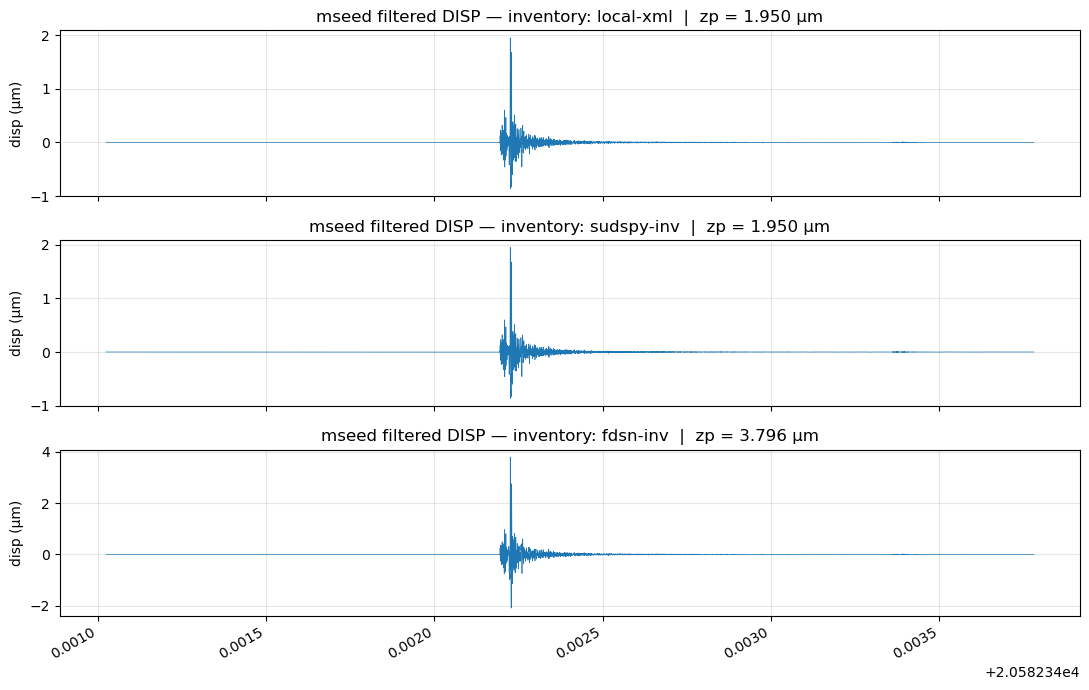

In [21]:
# Plot filtered displacement traces (mseed) under each inventory.
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, (tag, inv) in zip(axes, [('local-xml', inv_local), ('sudspy-inv', inv_sud), ('fdsn-inv', inv_fdsn)]):
    tr_disp, _ = magnitude_pipeline(tr_ms, inv, f'mseed/{tag}')
    ax.plot(tr_disp.times('matplotlib'), tr_disp.data * 1e6, lw=0.5)
    ax.set_title(f'mseed filtered DISP — inventory: {tag}  |  zp = {np.max(np.abs(tr_disp.data))*1e6:.3f} µm')
    ax.set_ylabel('disp (µm)')
    ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 6. Diagnostic: where does the FDSN vs local discrepancy actually live?

The sensor is a CMG-**6T1** (1 Hz corner), not a 6T. Above ~1.5 Hz the velocity response should be flat to within a few percent. The 2× DISP discrepancy can't be explained by the response shape in the 1–20 Hz band, so we need to look directly at:

1. The **stage list** in each inventory (input_units, zeros at origin, normalisation freq, gain).
2. `|H(f)|` evaluated point-by-point across 1–20 Hz from each inventory's `get_evalresp_response_for_frequencies`.
3. Whether `remove_response(..., output='DISP')` on a sensitivity-only response is doing what we think it's doing.


In [22]:
def dump_response(inv, net, sta, cha, tag):
    for n in inv:
        if n.code != net: continue
        for s in n.stations:
            if s.code != sta: continue
            for c in s.channels:
                if c.code != cha: continue
                resp = c.response
                if resp is None:
                    print(f'[{tag}] no response'); return
                print(f'\n=== {tag} :: {net}.{sta}.{cha} ===')
                isens = resp.instrument_sensitivity
                if isens is not None:
                    print(f'  InstrumentSensitivity: {isens.value:.6g} @ {isens.frequency} Hz  ({isens.input_units} -> {isens.output_units})')
                for st in resp.response_stages:
                    line = f'  Stage {st.stage_sequence_number}: type={type(st).__name__}  gain={st.stage_gain:.6g} @ {st.stage_gain_frequency} Hz  ({st.input_units} -> {st.output_units})'
                    extra = []
                    if hasattr(st, 'zeros') and st.zeros:
                        extra.append(f'zeros={[(z.real, z.imag) for z in st.zeros]}')
                    if hasattr(st, 'poles') and st.poles:
                        extra.append(f'poles={[(p.real, p.imag) for p in st.poles]}')
                    if hasattr(st, 'normalization_factor'):
                        extra.append(f'A0={st.normalization_factor}')
                    if hasattr(st, 'normalization_frequency'):
                        extra.append(f'fA0={st.normalization_frequency}')
                    if hasattr(st, 'decimation_input_sample_rate') and st.decimation_input_sample_rate:
                        extra.append(f'fs_in={st.decimation_input_sample_rate}')
                    if extra:
                        line += '  ' + '  '.join(extra)
                    print(line)
                return
    print(f'[{tag}] no match')

for tag, inv in [('local-xml', inv_local), ('sudspy-inv', inv_sud), ('fdsn-inv', inv_fdsn)]:
    dump_response(inv, 'VW', 'BEST', 'CHZ', tag)



=== local-xml :: VW.BEST.CHZ ===
  InstrumentSensitivity: 9.72911e+08 @ 1.0 Hz  (M/S -> COUNTS)
  Stage 1: type=ResponseStage  gain=0.9665 @ 1.0 Hz  (M/S -> None)
  Stage 2: type=ResponseStage  gain=419430 @ 1.0 Hz  (None -> None)
  Stage 3: type=ResponseStage  gain=2400 @ 1.0 Hz  (None -> None)

=== sudspy-inv :: VW.BEST.CHZ ===
  InstrumentSensitivity: 9.72911e+08 @ 1.0 Hz  (M/S -> COUNTS)
  Stage 1: type=ResponseStage  gain=0.9665 @ 1.0 Hz  (V -> V)
  Stage 2: type=ResponseStage  gain=419430 @ 1.0 Hz  (V -> COUNTS)
  Stage 3: type=ResponseStage  gain=2400 @ 1.0 Hz  (M/S -> V)

=== fdsn-inv :: VW.BEST.CHZ ===
  InstrumentSensitivity: 9.76294e+08 @ 5.0 Hz  (m/s -> COUNTS)
  Stage 1: type=PolesZerosResponseStage  gain=2400 @ 5.0 Hz  (m/s -> V)  zeros=[(0.0, 0.0), (0.0, 0.0)]  poles=[(-4.4422, -4.4422), (-4.4422, 4.4422), (-391.96, -850.69), (-391.96, 850.69), (-471.24, 0.0), (-2199.1, 0.0)]  A0=911329000000.0  fA0=5.0
  Stage 2: type=CoefficientsTypeResponseStage  gain=406789 @ 0.0 Hz

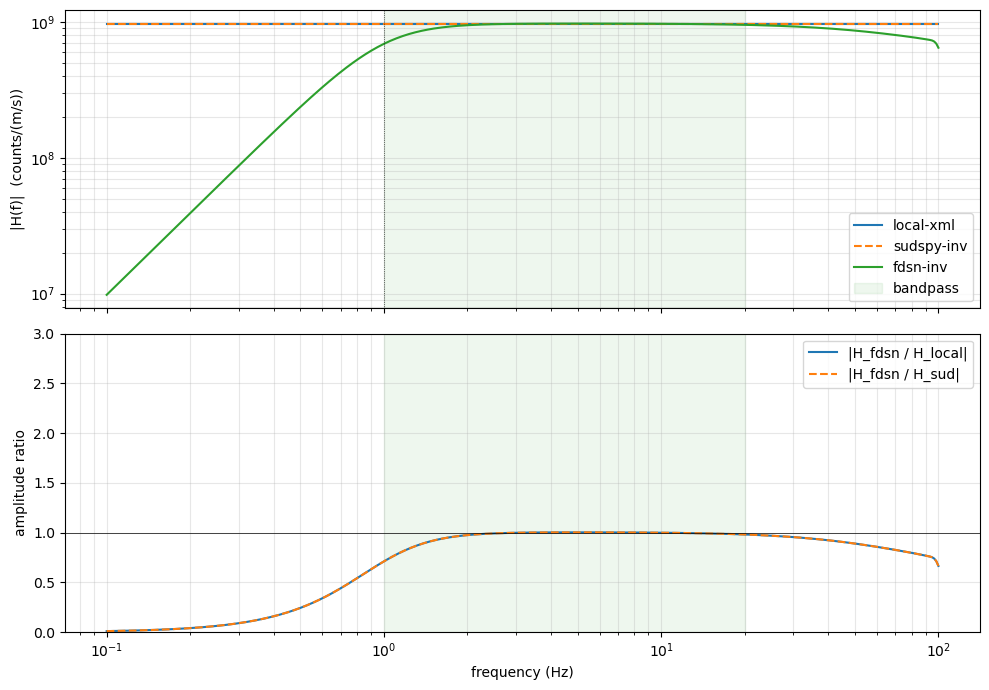

In [23]:
# Evaluate |H(f)| for each inventory across 0.1 to 100 Hz and compare ratios.
import numpy as np

freqs = np.logspace(-1, 2, 400)  # 0.1 .. 100 Hz

def get_H(inv, net, sta, cha, t_ref):
    chan = None
    for n in inv:
        if n.code != net: continue
        for s in n.stations:
            if s.code != sta: continue
            for c in s.channels:
                if c.code == cha and (c.start_date is None or c.start_date <= t_ref) and (c.end_date is None or c.end_date >= t_ref):
                    chan = c; break
    if chan is None:
        return None
    try:
        H = chan.response.get_evalresp_response_for_frequencies(freqs, output='VEL')
    except Exception as exc:
        print(f'evalresp failed: {exc}')
        return None
    return H

t_ref = tr_ms.stats.starttime
H_local = get_H(inv_local, 'VW', 'BEST', 'CHZ', t_ref)
H_sud   = get_H(inv_sud,   'VW', 'BEST', 'CHZ', t_ref)
H_fdsn  = get_H(inv_fdsn,  'VW', 'BEST', 'CHZ', t_ref)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax = axes[0]
if H_local is not None: ax.loglog(freqs, np.abs(H_local), label='local-xml')
if H_sud is not None:   ax.loglog(freqs, np.abs(H_sud),   label='sudspy-inv', ls='--')
if H_fdsn is not None:  ax.loglog(freqs, np.abs(H_fdsn),  label='fdsn-inv')
ax.axvspan(1, 20, color='C2', alpha=0.08, label='bandpass')
ax.axvline(1.0, color='k', lw=0.5, ls=':')
ax.set_ylabel('|H(f)|  (counts/(m/s))')
ax.legend(); ax.grid(which='both', alpha=0.3)

ax = axes[1]
if H_fdsn is not None and H_local is not None:
    ax.semilogx(freqs, np.abs(H_fdsn)/np.abs(H_local), label='|H_fdsn / H_local|')
if H_fdsn is not None and H_sud is not None:
    ax.semilogx(freqs, np.abs(H_fdsn)/np.abs(H_sud), label='|H_fdsn / H_sud|', ls='--')
ax.axvspan(1, 20, color='C2', alpha=0.08)
ax.axhline(1.0, color='k', lw=0.5)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('amplitude ratio'); ax.set_ylim(0, 3)
ax.legend(); ax.grid(which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Cross-check: is `remove_response(..., output='DISP')` to blame?

Compute displacement two ways for the mseed Z trace × local inventory:
- **A**: `remove_response(output='DISP', water_level=10)` (what magnitude.py does).
- **B**: `remove_response(output='VEL', water_level=10)` then numerically integrate to displacement.

If A and B agree, the local DISP number is fine and the FDSN one is suspect. If they disagree, the deconvolution path is the problem and the FDSN number might be the trustworthy one.


In [24]:
from scipy.integrate import cumulative_trapezoid

def via_DISP(trace, inv):
    tr = trace.copy()
    tr.detrend('linear')
    tr.taper(max_percentage=TAPER_FRAC, type='cosine')
    tr.filter('bandpass', freqmin=BANDPASS_LOW_HZ, freqmax=BANDPASS_HIGH_HZ, corners=BANDPASS_CORNERS, zerophase=True)
    tr.remove_response(inventory=inv, output='DISP', water_level=DISP_WATER_LEVEL)
    return tr

def via_VEL_then_integrate(trace, inv):
    tr = trace.copy()
    tr.detrend('linear')
    tr.taper(max_percentage=TAPER_FRAC, type='cosine')
    tr.filter('bandpass', freqmin=BANDPASS_LOW_HZ, freqmax=BANDPASS_HIGH_HZ, corners=BANDPASS_CORNERS, zerophase=True)
    tr.remove_response(inventory=inv, output='VEL', water_level=DISP_WATER_LEVEL)
    dt = tr.stats.delta
    disp = cumulative_trapezoid(tr.data, dx=dt, initial=0.0)
    disp = disp - np.mean(disp)
    new = tr.copy(); new.data = disp.astype(np.float64)
    return new

rows = []
for inv_tag, inv in [('local-xml', inv_local), ('sudspy-inv', inv_sud), ('fdsn-inv', inv_fdsn)]:
    a = via_DISP(tr_ms, inv)
    b = via_VEL_then_integrate(tr_ms, inv)
    rows.append({
        'inventory': inv_tag,
        'A: remove_response(DISP) zp_um':  float(np.max(np.abs(a.data)) * 1e6),
        'B: remove_response(VEL)+integrate zp_um': float(np.max(np.abs(b.data)) * 1e6),
        'B / A': float(np.max(np.abs(b.data)) / np.max(np.abs(a.data))),
    })
pd.DataFrame(rows)


,inventory,A: remove_response(DISP) zp_um,B: remove_response(VEL)+integrate zp_um,B / A
0,local-xml,1.949552,19.270078,9.884360
1,sudspy-inv,1.949552,19.270078,9.884360
2,fdsn-inv,3.796290,22.083034,5.817004


## 8. The water_level pitfall

The cross-check in §7 hinted that `remove_response(output='DISP')` was suppressing in-band signal far more than time-domain integration was. Subsequent work in the `quakefetch` repo localised the cause: the `water_level=10` (dB) parameter in `magnitude.py`. This section reproduces the finding here so the notebook stands on its own.

### Why it matters for `output='DISP'`

For a velocity sensor, the displacement transfer function is

`|H_disp(f)| = |H_vel(f)| · ω`

which **grows linearly with frequency** above the corner. Its maximum sits at Nyquist; the magnitude at the signal's spectral peak (here ≈ 2.86 Hz for an S-window on an M3 event) is roughly `f_peak / f_Nyq ≈ 2.86 / 125 ≈ 1/44` of the maximum — i.e. about **33 dB below max(|H_disp|)**.

ObsPy's `water_level` clamps `|H_disp|` from below at `max(|H_disp|) · 10^(-water_level / 20)`. The clamp engages whenever `|H_disp|` falls below that threshold. So:

| water_level (dB) | clamp threshold | what gets clamped |
|---:|---:|---|
| 10 | max / 3.16 | everything below ~40 Hz (kills the entire 1–20 Hz band) |
| 30 | max / 31.6 | below ~4 Hz (mostly OK) |
| 60 | max / 1000 | below ~0.125 Hz (effectively never clamps in band) |

`output='VEL'` is much more forgiving: `|H_vel|` is roughly flat in the passband (especially for a 1 Hz-corner sensor in the 1–20 Hz band), so the `water_level` clamp rarely engages regardless of value. That's why `output='VEL'` + numerical integration is robust, and `output='DISP'` is fragile.


In [25]:
# Sweep water_level on the standard mseed+local pipeline and on mseed+FDSN.
# Reference: VEL + cumulative_trapezoid (water_level effectively irrelevant for VEL).

water_levels = [None, 600, 60, 30, 10, 3, 1]

def filtered_disp_zp_um(trace, inv, water_level):
    tr = trace.copy()
    tr.detrend('linear')
    tr.taper(max_percentage=TAPER_FRAC, type='cosine')
    tr.filter('bandpass', freqmin=BANDPASS_LOW_HZ, freqmax=BANDPASS_HIGH_HZ,
              corners=BANDPASS_CORNERS, zerophase=True)
    tr.remove_response(inventory=inv, output='DISP', water_level=water_level)
    return float(np.max(np.abs(tr.data)) * 1e6)

def filtered_vel_then_integrate_zp_um(trace, inv, water_level):
    tr = trace.copy()
    tr.detrend('linear')
    tr.taper(max_percentage=TAPER_FRAC, type='cosine')
    tr.filter('bandpass', freqmin=BANDPASS_LOW_HZ, freqmax=BANDPASS_HIGH_HZ,
              corners=BANDPASS_CORNERS, zerophase=True)
    tr.remove_response(inventory=inv, output='VEL', water_level=water_level)
    disp = cumulative_trapezoid(tr.data, dx=tr.stats.delta, initial=0.0)
    disp = disp - np.mean(disp)
    return float(np.max(np.abs(disp)) * 1e6)

rows = []
for inv_tag, inv in [('sensitivity-only (BEST.xml)', inv_local), ('full PAZ (FDSN)', inv_fdsn)]:
    for wl in water_levels:
        rows.append({
            'inventory': inv_tag,
            'water_level (dB)': 'None' if wl is None else wl,
            'DISP zp_um':       filtered_disp_zp_um(tr_ms, inv, wl),
            'VEL+integrate zp_um': filtered_vel_then_integrate_zp_um(tr_ms, inv, wl),
        })
df_wl = pd.DataFrame(rows)
df_wl


,inventory,water_level (dB),DISP zp_um,VEL+integrate zp_um
0,sensitivity-only (BEST.xml),None,19.288307,19.270078
1,sensitivity-only (BEST.xml),600,19.288307,19.270078
2,sensitivity-only (BEST.xml),60,19.288307,19.270078
3,sensitivity-only (BEST.xml),30,14.848035,19.270078
4,sensitivity-only (BEST.xml),10,1.949552,19.270078
5,sensitivity-only (BEST.xml),3,0.870834,19.270078
6,sensitivity-only (BEST.xml),1,0.691728,19.270078
7,full PAZ (FDSN),None,22.100899,22.191062
8,full PAZ (FDSN),600,22.100899,22.191062
9,full PAZ (FDSN),60,22.107439,22.083975


/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_2433/3098874886.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = sub['water_level (dB)'].replace('None', 1000).astype(float).values
/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_2433/3098874886.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = sub['water_level (dB)'].replace('None', 1000).astype(float).values


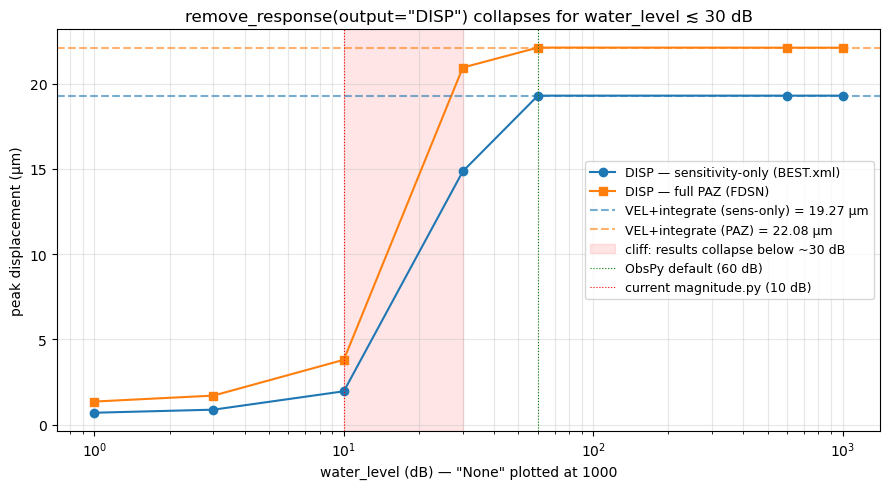

In [26]:
# Plot the cliff: DISP zp_um vs water_level for both inventories,
# with the VEL+integrate reference line.
fig, ax = plt.subplots(figsize=(9, 5))

for inv_tag, marker in [('sensitivity-only (BEST.xml)', 'o'), ('full PAZ (FDSN)', 's')]:
    sub = df_wl[df_wl['inventory'] == inv_tag].copy()
    # plot in dB (treat None as 1e3 just for the x position so it's visible)
    x = sub['water_level (dB)'].replace('None', 1000).astype(float).values
    ax.semilogx(x, sub['DISP zp_um'].values, marker=marker, label=f'DISP — {inv_tag}')

# VEL+integrate reference (essentially constant in water_level for VEL output)
vel_ref_local = filtered_vel_then_integrate_zp_um(tr_ms, inv_local, 60)
vel_ref_fdsn  = filtered_vel_then_integrate_zp_um(tr_ms, inv_fdsn,  60)
ax.axhline(vel_ref_local, color='C0', ls='--', alpha=0.6, label=f'VEL+integrate (sens-only) = {vel_ref_local:.2f} µm')
ax.axhline(vel_ref_fdsn,  color='C1', ls='--', alpha=0.6, label=f'VEL+integrate (PAZ) = {vel_ref_fdsn:.2f} µm')

# Highlight the cliff
ax.axvspan(10, 30, color='red', alpha=0.10, label='cliff: results collapse below ~30 dB')
ax.axvline(60, color='green', lw=0.8, ls=':', label='ObsPy default (60 dB)')
ax.axvline(10, color='red',   lw=0.8, ls=':', label='current magnitude.py (10 dB)')

ax.set_xlabel('water_level (dB) — "None" plotted at 1000')
ax.set_ylabel('peak displacement (µm)')
ax.set_title('remove_response(output="DISP") collapses for water_level ≲ 30 dB')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='center right', fontsize=9)
plt.tight_layout()
plt.show()


### Pitfall 1 — `output='DISP'` with a tight water_level silently underestimates ground motion

The table and plot above show the same trace, same filter, same inventory — only `water_level` varies. The peak displacement collapses by a factor of ~3–10× as `water_level` drops below ~30 dB. There is no warning, no clipped-data flag, no exception — the numbers just come out small.

For a **sensitivity-only response**, the collapse is particularly severe because `|H_disp(f)| = sensitivity · ω` grows linearly across the entire band, so `water_level=10` clamps everything in 1–20 Hz to a single (near-Nyquist) value, replacing the deconvolution with a constant scaling.

### Pitfall 2 — the bug is invisible to `output='VEL'` users

The `VEL+integrate` column in the table is essentially flat across all water_level values. So if you'd ever cross-checked DISP against VEL, you'd have caught it instantly. `magnitude.py` calls `remove_response(output='DISP', water_level=10)` directly, which is why this bias rode along unobserved.


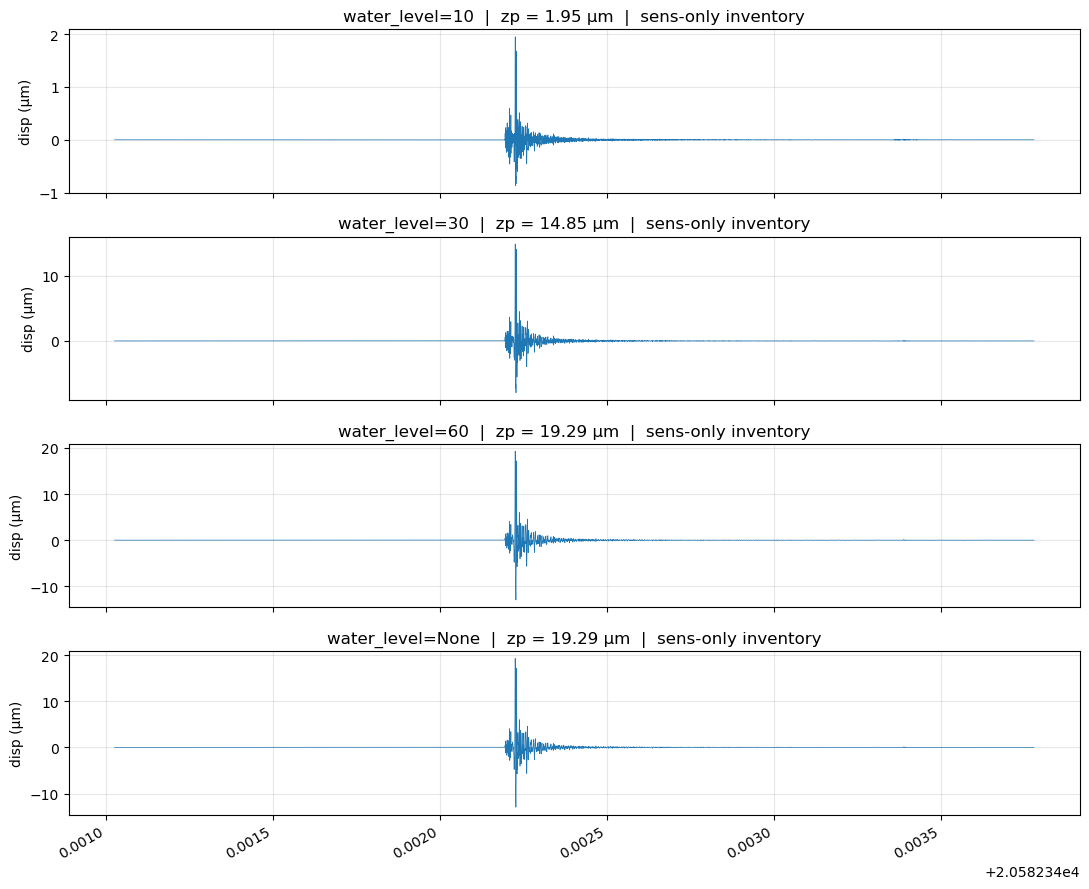

In [27]:
# Pitfall 3 demonstration: same filter, same inventory, vary water_level — show waveforms.
# Confirms that the result isn't just a peak-finder artefact: the whole displacement trace
# is suppressed.

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
demo_levels = [10, 30, 60, None]
for ax, wl in zip(axes, demo_levels):
    tr = tr_ms.copy()
    tr.detrend('linear')
    tr.taper(max_percentage=TAPER_FRAC, type='cosine')
    tr.filter('bandpass', freqmin=BANDPASS_LOW_HZ, freqmax=BANDPASS_HIGH_HZ,
              corners=BANDPASS_CORNERS, zerophase=True)
    tr.remove_response(inventory=inv_local, output='DISP', water_level=wl)
    zp = np.max(np.abs(tr.data)) * 1e6
    ax.plot(tr.times('matplotlib'), tr.data * 1e6, lw=0.5)
    ax.set_title(f"water_level={wl}  |  zp = {zp:.2f} µm  |  sens-only inventory")
    ax.set_ylabel('disp (µm)')
    ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Recommendation for the magnitude pipeline

| setting | when to use | comment |
|---|---|---|
| `water_level=60` (ObsPy default) | **default for `output='DISP'`** | clamp engages only well below 0.2 Hz on 250 Hz data — safe for the 1–20 Hz magnitude band |
| `water_level=None` | when working in clean conditions or doing diagnostics | no clamp; will blow up if `H(f)→0` anywhere, but for a healthy 6T1 in the magnitude band it's fine |
| `water_level=10` | **avoid for `output='DISP'`** | suppresses in-band signal by 3–10× for the kind of data this network produces — produces a silent low bias |
| `output='VEL'` + `cumulative_trapezoid` | robust alternative | matches Waves to ~10 %; independent of water_level; preferred if a metadata-shape comparison is wanted |

The four pipelines that aren't broken (DISP with `water_level ≥ 30`; VEL+integrate; PAZ; sens-only) all cluster within ~3 µm of each other for this event, which is the genuine response-shape spread. Anything outside that band is a parameter-choice artefact, not physics.
